In [1]:
import numpy as np
import torch
import torch.nn as nn

import sys
sys.path.insert(0, '../include')

from phase_shifts import compute_phase_shifts, fit_potential, convert_to_wavenumber
from plot import plot_wavefunction, plot_wavefunctions
from sampling import TrainConfig
from scipy_eigensolver import solve_1channel
from training import train_Rayleigh, train_Rayleigh_PDE
from validation import validate, print_metrics

## Fit parameters from ³S₁ phase shifts

Use the Stoks *et al.* PRC 48 (1993) 792 data (low-energy subset, $T_\mathrm{lab} \leq 100$ MeV)
to fit the two Yukawa parameters $g$ and $a$ by minimising

$$\chi^2 = \sum_i \bigl[\delta_0(k_i;\, g, a) - \tilde\delta(k_i)\bigr]^2, \qquad V(r) = -\frac{g^2\,e^{-r/a}}{r}$$

Simple central potentials cannot reproduce the high-energy phase shifts (missing repulsive core),
so we restrict the fit to the low-energy region where the potential shape is most constrained.

In [4]:
# Stoks et al., PRC 48 (1993) 792, Table V  (low-energy subset, Tlab <= 100 MeV)
Tlab   = np.array([1, 5, 10, 25, 50], dtype=float)
np_3S1 = np.array([147.747, 118.178, 102.611, 80.63, 62.77])
k_exp, _ = convert_to_wavenumber(Tlab, input_type='T_lab')

# Yukawa template:  V(r) = -g^2 * exp(-r/a) / r   (clamped to avoid 1/r singularity)
def V_yukawa(r, g, a):
    r_safe = np.maximum(r, 1e-2)
    return -g**2 * np.exp(-r_safe / a) / r_safe

params_opt, res = fit_potential(
    V_yukawa,
    params_init=[8.0, 1.5],
    k_data=k_exp, delta_data=np_3S1,
    bounds=[(1.0, 50.0), (0.5, 5.0)],
    n_bound_states=1,
)
g, a = params_opt
mu = 1.0 / a

print(f'Fitted parameters:')
print(f'  g  = {g:.4f} MeV^(1/2)')
print(f'  a  = {a:.4f} fm    mu = {mu:.4f} fm^-1')
print(f'  chi2 = {res.fun:.4g}   converged: {res.success}')
print()

delta_fit = compute_phase_shifts(lambda r: V_yukawa(r, *params_opt), k_exp, n_bound_states=1)
print(f'{"Tlab":>6}  {"data":>8}  {"fit":>8}  {"resid":>7}')
for Tl, de, df in zip(Tlab, np_3S1, delta_fit):
    print(f'{Tl:6.0f}  {de:8.3f}  {df:8.3f}  {df-de:+7.3f}')

r_min = 1e-4
r_max = 30.0
r = np.linspace(r_min, r_max, 1000)

Fitted parameters:
  g  = 6.1170 MeV^(1/2)
  a  = 4.0348 fm    mu = 0.2478 fm^-1
  chi2 = 16.57   converged: True

  Tlab      data       fit    resid
     1   147.747   149.242   +1.495
     5   118.178   117.185   -0.993
    10   102.611   100.778   -1.833
    25    80.630    79.930   -0.700
    50    62.770    65.851   +3.081


Solve with scipy

Ground state energy E = -2.132402 MeV


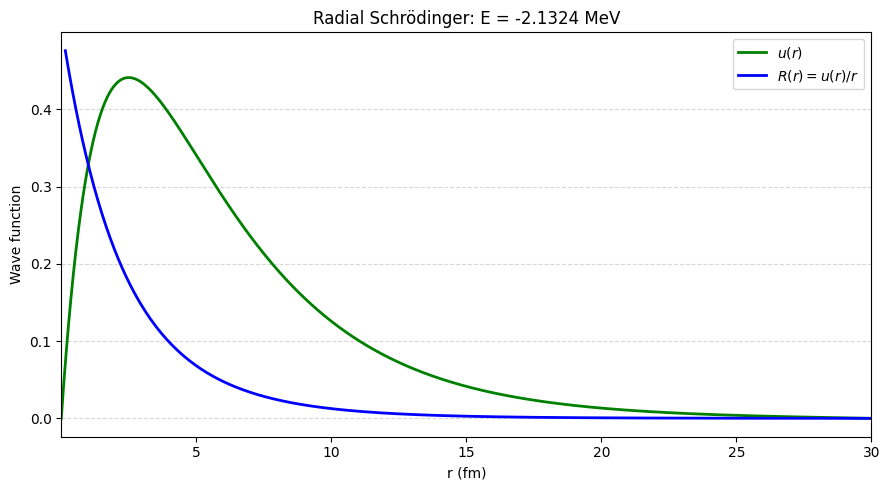

In [5]:
def V(r):
    return - g**2 * np.exp(-mu * r) /  np.maximum(r, 1e-2)

E_scipy, u_scipy, R_scipy = solve_1channel(V, r)
plot_wavefunction(r, u_scipy, R_scipy, E_scipy)

Define a neural network $N_\theta(r)$ that approximates the radial wave function via an ansatz
$$
u_\theta(r) = r e^{-\alpha r} N_{\theta}(r) \text{ with } \alpha = 0.25 \text{ fm}^{-1}.
$$
The network input is rescaled from $[0,r_{\max}]$ to $[-1,1]$.

In [6]:
class RadialNet(nn.Module):
    def __init__(self, hidden_dim=64, num_layers=3, alpha=0.25, energy_init=-3.0):
        # Define layers
        super().__init__()
        layers = [nn.Linear(1, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

        self.register_buffer('alpha', torch.tensor(float(alpha)))
        self.energy = nn.Parameter(torch.tensor([energy_init], dtype=torch.float32))

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.dtype = torch.float32

        self.r_min = r_min
        self.r_max = r_max
        self.R = None

    # Forward pass
    def forward(self, r):
        # r is expected to be of shape (N, 1)
        x = 2.0 * r / self.r_max - 1.0 # mapping to [-1,1]
        return r * torch.exp(-self.alpha * r) * self.net(x)

    # Potential
    def potential(self, r):
        return -g**2 * torch.exp(-mu * r) / r

Train with Rayleigh energy only

In [7]:
cfg = TrainConfig()
cfg.n_rayleigh = 8000

model = RadialNet()

history = train_Rayleigh(model, cfg, stop=1e-3)

{'step': 1, 'loss': 8.596985816955566, 'rayleigh': -0.8916195034980774, 'norm_loss': 0.9488561749458313, 'boundary_loss': 4.413660462887492e-06, 'E': -0.8916195034980774}
{'step': 500, 'loss': -2.1778976917266846, 'rayleigh': -2.1855578422546387, 'norm_loss': 0.0007652543717995286, 'boundary_loss': 7.638237207174825e-07, 'E': -2.1855578422546387}
{'step': 1000, 'loss': -2.4114596843719482, 'rayleigh': -2.4159767627716064, 'norm_loss': 0.00045031995978206396, 'boundary_loss': 1.3815158581564901e-06, 'E': -2.4159767627716064}
{'step': 1500, 'loss': -2.272510528564453, 'rayleigh': -2.273667335510254, 'norm_loss': 0.00011435456690378487, 'boundary_loss': 1.342340738119674e-06, 'E': -2.273667335510254}
{'step': 2000, 'loss': -2.2777814865112305, 'rayleigh': -2.2787344455718994, 'norm_loss': 9.350004984298721e-05, 'boundary_loss': 1.7866226471596747e-06, 'E': -2.2787344455718994}
{'step': 2500, 'loss': -2.3938095569610596, 'rayleigh': -2.397900342941284, 'norm_loss': 0.0004071597068104893, '

In [8]:
metrics, u_nn, R_nn = validate(r, u_scipy, R_scipy, E_scipy, model)
print_metrics(metrics)

  rayleigh_energy: -2.1313062
  norm_loss: 0.0022322277
  pde_loss: 0.01179381
  u_rmax: 0.001434308
  l2: 0.012293144
  learned_energy: -2.1867876
  energy_error: 0.05438525


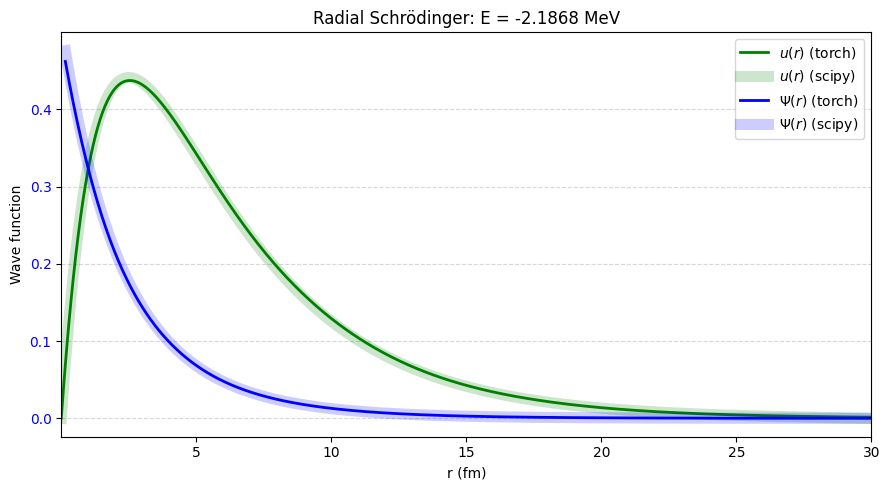

In [9]:
plot_wavefunctions(r, u_scipy, R_scipy, u_nn, R_nn, metrics['learned_energy'])

Train with both Rayleigh and PDE terms

In [10]:
cfg2 = TrainConfig()
cfg2.n_origin = 2000
cfg2.n_pde = 3000
cfg2.origin_width = 0.6

model2 = RadialNet()

history2 = train_Rayleigh_PDE(model2, cfg2, stop=1e-3)

{'step': 1, 'loss': 8.778932571411133, 'rayleigh': -0.7731189131736755, 'pde_loss': 0.04737255722284317, 'match_loss': 4.958999156951904, 'norm_loss': 0.9551961421966553, 'boundary_loss': 8.922527740651276e-06, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 500, 'loss': -2.12064528465271, 'rayleigh': -2.138822555541992, 'pde_loss': 0.8117679953575134, 'match_loss': 0.7416266202926636, 'norm_loss': 0.0018167999805882573, 'boundary_loss': 9.346991305392294e-07, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 1000, 'loss': -1.5839265584945679, 'rayleigh': -1.5891190767288208, 'pde_loss': 0.2655465304851532, 'match_loss': 1.9905849695205688, 'norm_loss': 0.0005180679727345705, 'boundary_loss': 1.1756958429032238e-06, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 1500, 'loss': -2.059239387512207, 'rayleigh': -2.061669111251831, 'pde_loss': 0.2823481559753418, 'match_loss': 0.8804648518562317, 'norm_loss': 0.00024194765137508512, 'boundary_loss': 1.0309

In [11]:
metrics2, u_nn2, R_nn2 = validate(r, u_scipy, R_scipy, E_scipy, model2)
print_metrics(metrics2)

  rayleigh_energy: -2.1322536
  norm_loss: 0.0010651505
  pde_loss: 0.00076373102
  u_rmax: 0.0014641691
  l2: 0.0049891354
  learned_energy: -2.1155231
  energy_error: 0.016879255


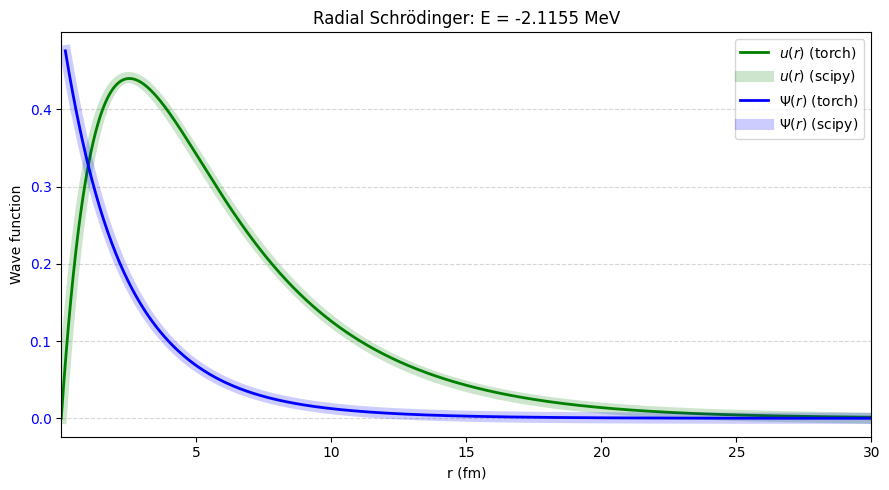

In [12]:
plot_wavefunctions(r, u_scipy, R_scipy, u_nn2, R_nn2, metrics2['learned_energy'])